In [ ]:
!pip install gradio scikit-learn pandas openpyxl --quiet

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cardekho_dataset.csv.xlsx to cardekho_dataset.csv.xlsx


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# ── Load ──────────────────────────────────────────────────────
df = pd.read_excel('cardekho_dataset.csv.xlsx').dropna()

# ── Outlier removal ───────────────────────────────────────────
q_low  = df['selling_price'].quantile(0.01)
q_high = df['selling_price'].quantile(0.99)
df = df[(df['selling_price'] >= q_low) & (df['selling_price'] <= q_high)].copy()

# ── Encode categoricals ───────────────────────────────────────
cat_cols = ['Brand', 'Fuel_type', 'Seller_type', 'Transmission_type']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    encoders[col] = le

# ── Train ─────────────────────────────────────────────────────
FEATURES = ['Brand_enc','Vehicle_Age','Km_driven','Fuel_type_enc',
            'Seller_type_enc','Transmission_type_enc','Mileage',
            'Engine','max_power','seats']

X = df[FEATURES]
y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                   learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
R2  = r2_score(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)

print(f"✅ Model ready  |  R² = {R2*100:.1f}%  |  MAE = ₹{MAE:,.0f}")

# ── Helper lookups ────────────────────────────────────────────
BRANDS       = sorted(df['Brand'].unique().tolist())
FUEL_TYPES   = sorted(df['Fuel_type'].unique().tolist())
SELLER_TYPES = sorted(df['Seller_type'].unique().tolist())
TRANS_TYPES  = sorted(df['Transmission_type'].unique().tolist())
SEATS_LIST   = sorted([int(s) for s in df['seats'].unique() if s > 0])

brand_defaults = {
    b: {
        'mileage':   round(float(df[df['Brand']==b]['Mileage'].mean()), 1),
        'engine':    int(df[df['Brand']==b]['Engine'].mean()),
        'max_power': round(float(df[df['Brand']==b]['max_power'].mean()), 1),
    }
    for b in BRANDS
}

✅ Model ready  |  R² = 93.6%  |  MAE = ₹89,812


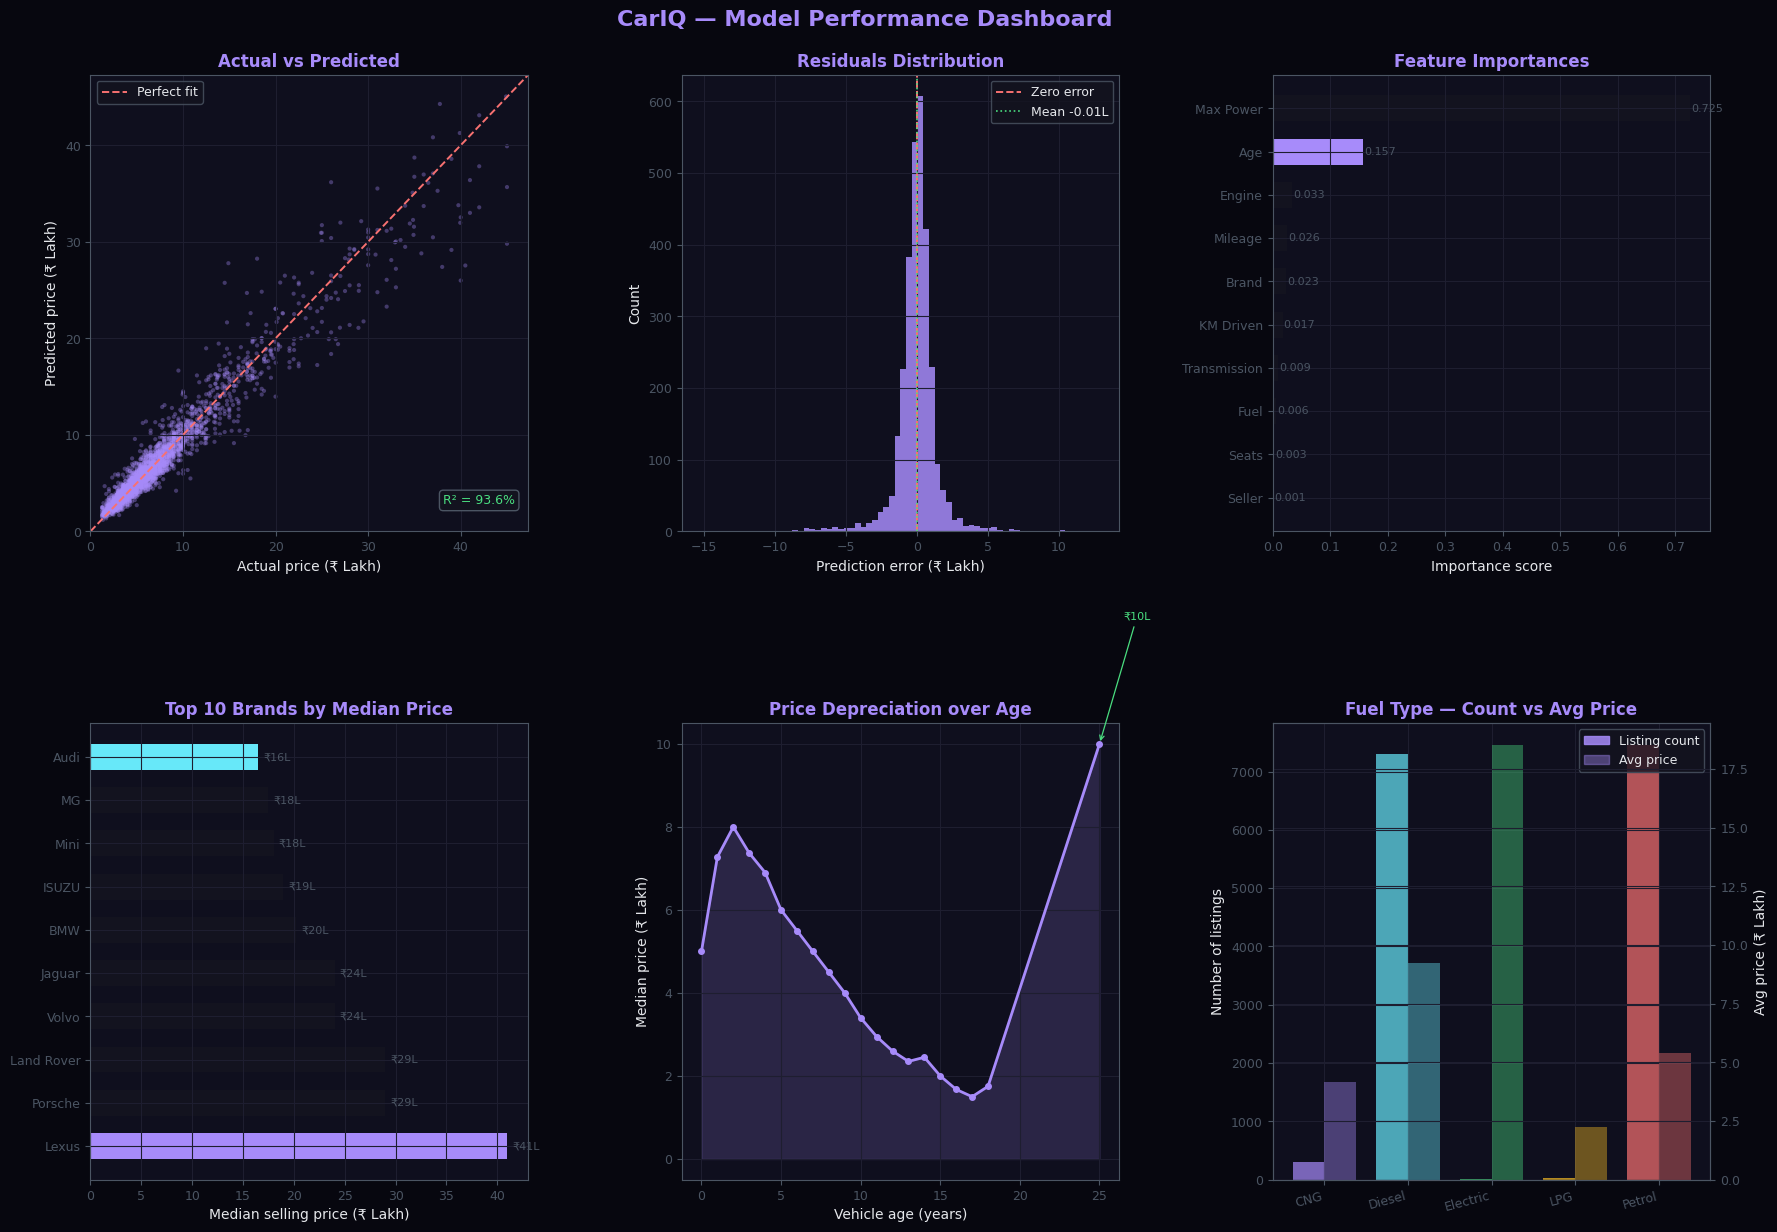

✅ Dashboard saved as cariq_dashboard.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

# ── Theme ─────────────────────────────────────────────────────
BG       = "#07070f"
SURFACE  = "#0f0f1e"
SURFACE2 = "#13131f"
ACCENT   = "#a78bfa"
ACCENT2  = "#67e8f9"
ACCENT3  = "#4ade80"
MUTED    = "#4b5563"
TEXT     = "#e5e7eb"
RED      = "#f87171"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    SURFACE,
    "axes.edgecolor":    MUTED,
    "axes.labelcolor":   TEXT,
    "axes.titlecolor":   ACCENT,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "axes.grid":         True,
    "grid.color":        "#1e1e30",
    "grid.linewidth":    0.8,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "text.color":        TEXT,
    "font.family":       "sans-serif",
    "legend.facecolor":  SURFACE2,
    "legend.edgecolor":  MUTED,
    "legend.fontsize":   9,
})

fig = plt.figure(figsize=(18, 13), facecolor=BG)
fig.suptitle("CarIQ — Model Performance Dashboard",
             fontsize=16, fontweight="bold", color=ACCENT,
             y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.42, wspace=0.35,
                       left=0.07, right=0.97,
                       top=0.93, bottom=0.08)

# ── 1. Actual vs Predicted ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
actual = y_test.values / 1e5
predicted = model.predict(X_test) / 1e5

ax1.scatter(actual, predicted, alpha=0.35, s=9,
            color=ACCENT, edgecolors="none", rasterized=True)
lim = max(actual.max(), predicted.max()) * 1.05
ax1.plot([0, lim], [0, lim], "--", color=RED,
         linewidth=1.4, label="Perfect fit")
ax1.set_xlim(0, lim); ax1.set_ylim(0, lim)
ax1.set_xlabel("Actual price (₹ Lakh)")
ax1.set_ylabel("Predicted price (₹ Lakh)")
ax1.set_title("Actual vs Predicted")
ax1.legend()
ax1.text(0.97, 0.06, f"R² = {R2*100:.1f}%",
         transform=ax1.transAxes, ha="right",
         fontsize=9, color=ACCENT3,
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor=SURFACE2, edgecolor=MUTED))

# ── 2. Residuals distribution ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
residuals = predicted - actual
ax2.hist(residuals, bins=70, color=ACCENT,
         alpha=0.85, edgecolor="none", rasterized=True)
ax2.axvline(0, color=RED, linewidth=1.4,
            linestyle="--", label="Zero error")
ax2.axvline(residuals.mean(), color=ACCENT3,
            linewidth=1.2, linestyle=":", label=f"Mean {residuals.mean():.2f}L")
ax2.set_xlabel("Prediction error (₹ Lakh)")
ax2.set_ylabel("Count")
ax2.set_title("Residuals Distribution")
ax2.legend()

# ── 3. Feature importances ─────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
feat_labels = ["Brand", "Age", "KM Driven", "Fuel",
               "Seller", "Transmission", "Mileage",
               "Engine", "Max Power", "Seats"]
importances = model.feature_importances_
order       = np.argsort(importances)

colors = [ACCENT if i == order[-1] else
          ACCENT2 if i == order[-2] else
          SURFACE2 for i in range(len(order))]

bars = ax3.barh([feat_labels[i] for i in order],
                importances[order],
                color=[colors[i] for i in range(len(order))],
                edgecolor="none", height=0.6)
ax3.set_xlabel("Importance score")
ax3.set_title("Feature Importances")
for bar, val in zip(bars, importances[order]):
    ax3.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=8, color=MUTED)

# ── 4. Price distribution by brand (top 10) ────────────────
ax4 = fig.add_subplot(gs[1, 0])
top_brands = (df.groupby("Brand")["selling_price"]
              .median()
              .sort_values(ascending=False)
              .head(10))
brand_names = [b[:10] for b in top_brands.index]
vals_lac    = top_brands.values / 1e5

bar_colors = [ACCENT if v == vals_lac.max() else
              ACCENT2 if v == vals_lac.min() else
              SURFACE2 for v in vals_lac]

ax4.barh(brand_names, vals_lac,
         color=bar_colors, edgecolor="none", height=0.6)
ax4.set_xlabel("Median selling price (₹ Lakh)")
ax4.set_title("Top 10 Brands by Median Price")
for i, v in enumerate(vals_lac):
    ax4.text(v + 0.5, i, f"₹{v:.0f}L",
             va="center", fontsize=8, color=MUTED)

# ── 5. Selling price vs Vehicle Age ────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
age_avg = (df.groupby("Vehicle_Age")["selling_price"]
           .median() / 1e5)
ages = age_avg.index.values
vals = age_avg.values

ax5.fill_between(ages, vals, alpha=0.18, color=ACCENT)
ax5.plot(ages, vals, color=ACCENT,
         linewidth=2, marker="o", markersize=4)
ax5.set_xlabel("Vehicle age (years)")
ax5.set_ylabel("Median price (₹ Lakh)")
ax5.set_title("Price Depreciation over Age")

# annotate peak
peak_age = ages[np.argmax(vals)]
peak_val = vals.max()
ax5.annotate(f"₹{peak_val:.0f}L",
             xy=(peak_age, peak_val),
             xytext=(peak_age + 1.5, peak_val + 3),
             fontsize=8, color=ACCENT3,
             arrowprops=dict(arrowstyle="->",
                             color=ACCENT3, lw=0.9))

# ── 6. Fuel type count + avg price ─────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
fuel_stats = (df.groupby("Fuel_type")["selling_price"]
              .agg(["count", "mean"]))
fuel_stats["mean_lac"] = fuel_stats["mean"] / 1e5
fuels = fuel_stats.index.tolist()
x     = np.arange(len(fuels))
width = 0.38

fuel_colors = [ACCENT, ACCENT2, ACCENT3, "#fbbf24", RED][:len(fuels)]
ax6b = ax6.twinx()

ax6.bar(x - width/2, fuel_stats["count"],
        width, color=fuel_colors, alpha=0.7, edgecolor="none",
        label="Count")
ax6b.bar(x + width/2, fuel_stats["mean_lac"],
         width, color=fuel_colors, alpha=0.4, edgecolor="none",
         label="Avg Price")

ax6.set_xticks(x)
ax6.set_xticklabels(fuels, rotation=15, ha="right")
ax6.set_ylabel("Number of listings", color=TEXT)
ax6b.set_ylabel("Avg price (₹ Lakh)", color=TEXT)
ax6.set_title("Fuel Type — Count vs Avg Price")

p1 = mpatches.Patch(color=ACCENT,  alpha=0.85, label="Listing count")
p2 = mpatches.Patch(color=ACCENT,  alpha=0.40, label="Avg price")
ax6.legend(handles=[p1, p2], loc="upper right")

# ── Save & show ───────────────────────────────────────────
plt.savefig("cariq_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("✅ Dashboard saved as cariq_dashboard.png")

In [ ]:
def predict_price(brand, vehicle_age, km_driven, fuel_type,
                  seller_type, transmission, mileage, engine,
                  max_power, seats):
    try:
        feats = [[
            encoders['Brand'].transform([brand])[0],
            int(vehicle_age), int(km_driven),
            encoders['Fuel_type'].transform([fuel_type])[0],
            encoders['Seller_type'].transform([seller_type])[0],
            encoders['Transmission_type'].transform([transmission])[0],
            float(mileage), int(engine), float(max_power), int(seats)
        ]]

        price     = model.predict(feats)[0]
        price_lac = price / 1e5
        low       = price * 0.88 / 1e5
        high      = price * 1.12 / 1e5

        # Similar cars
        mask = (
            (df['Brand'] == brand) &
            (df['Fuel_type'] == fuel_type) &
            (df['Transmission_type'] == transmission) &
            (df['Vehicle_Age'].between(max(0, vehicle_age - 2), vehicle_age + 2))
        )
        sim_count  = int(mask.sum())
        sim_avg    = df[mask]['selling_price'].mean() / 1e5 if sim_count > 0 else price_lac
        diff       = price_lac - sim_avg
        diff_sign  = "+" if diff >= 0 else "-"
        diff_color = "#4ade80" if diff >= 0 else "#f87171"
        diff_label = "above" if diff >= 0 else "below"

        # Condition
        if vehicle_age <= 2:
            cond_color, cond_dot, cond_text = "#4ade80", "#4ade80", "Excellent condition"
        elif vehicle_age <= 5:
            cond_color, cond_dot, cond_text = "#fbbf24", "#fbbf24", "Good condition"
        elif vehicle_age <= 9:
            cond_color, cond_dot, cond_text = "#fb923c", "#fb923c", "Fair condition"
        else:
            cond_color, cond_dot, cond_text = "#f87171", "#f87171", "High usage"

        # Range bar — pin position as %
        total = high - low
        pin_pct = ((price_lac - low) / total * 80 + 10) if total > 0 else 50

        html = f"""
<div style="background:#07070f;border-radius:14px;padding:4px;font-family:'Inter','Segoe UI',sans-serif;">
  <div style="background:#0f0f1e;border:1px solid rgba(167,139,250,0.2);border-radius:14px;overflow:hidden;">

    <!-- Header -->
    <div style="background:#12122a;border-bottom:1px solid rgba(167,139,250,0.1);
                padding:14px 20px;display:flex;align-items:center;justify-content:space-between;">
      <span style="font-size:10px;font-weight:600;letter-spacing:0.12em;
                   text-transform:uppercase;color:#6b7280;">Valuation Report</span>
      <span style="display:flex;align-items:center;gap:5px;
                   background:rgba({','.join(str(int(cond_color.lstrip('#')[i:i+2],16)) for i in (0,2,4))},0.1);
                   border:1px solid rgba({','.join(str(int(cond_color.lstrip('#')[i:i+2],16)) for i in (0,2,4))},0.25);
                   border-radius:20px;padding:3px 10px;font-size:10px;color:{cond_color};">
        <span style="width:6px;height:6px;border-radius:50%;
                     background:{cond_dot};display:inline-block;"></span>
        {cond_text}
      </span>
    </div>

    <!-- Price -->
    <div style="padding:24px 20px 18px;text-align:center;
                border-bottom:1px solid rgba(255,255,255,0.05);">
      <div style="font-size:10px;color:#6b7280;text-transform:uppercase;
                  letter-spacing:0.1em;margin-bottom:8px;">Estimated Market Value</div>
      <div style="font-size:2.8rem;font-weight:800;color:#a78bfa;
                  letter-spacing:-0.04em;line-height:1;font-family:monospace;">
        &#8377;&nbsp;{price_lac:.2f}
        <span style="font-size:1rem;font-weight:400;color:#6b7280;">Lakh</span>
      </div>

      <!-- Range bar -->
      <div style="margin:16px auto 0;max-width:300px;">
        <div style="display:flex;justify-content:space-between;
                    font-size:10px;color:#6b7280;margin-bottom:5px;">
          <span>Low &nbsp;&#8377;{low:.2f}L</span>
          <span>High &nbsp;&#8377;{high:.2f}L</span>
        </div>
        <div style="height:5px;background:rgba(255,255,255,0.07);
                    border-radius:5px;position:relative;">
          <div style="position:absolute;left:10%;right:10%;top:0;height:100%;
                      background:#7c3aed;border-radius:5px;"></div>
          <div style="position:absolute;top:-5px;
                      left:calc({pin_pct:.0f}% - 8px);
                      width:16px;height:16px;border-radius:50%;
                      background:#a78bfa;border:2px solid #07070f;"></div>
        </div>
        <div style="font-size:10px;color:#4b5563;text-align:center;margin-top:5px;">
          ±12% confidence interval
        </div>
      </div>
    </div>

    <!-- 3 metric tiles -->
    <div style="display:grid;grid-template-columns:repeat(3,1fr);
                gap:1px;background:rgba(255,255,255,0.05);
                border-bottom:1px solid rgba(255,255,255,0.05);">
      <div style="background:#0f0f1e;padding:14px 10px;text-align:center;">
        <span style="font-size:1.05rem;font-weight:700;color:#a78bfa;
                     display:block;font-family:monospace;">{R2*100:.1f}%</span>
        <span style="font-size:9px;color:#4b5563;text-transform:uppercase;
                     letter-spacing:0.08em;margin-top:2px;display:block;">Model accuracy</span>
      </div>
      <div style="background:#0f0f1e;padding:14px 10px;text-align:center;">
        <span style="font-size:1.05rem;font-weight:700;color:#67e8f9;
                     display:block;font-family:monospace;">{sim_count}</span>
        <span style="font-size:9px;color:#4b5563;text-transform:uppercase;
                     letter-spacing:0.08em;margin-top:2px;display:block;">Similar listings</span>
      </div>
      <div style="background:#0f0f1e;padding:14px 10px;text-align:center;">
        <span style="font-size:1.05rem;font-weight:700;color:{diff_color};
                     display:block;font-family:monospace;">
          {diff_sign}&#8377;{abs(diff):.2f}L
        </span>
        <span style="font-size:9px;color:#4b5563;text-transform:uppercase;
                     letter-spacing:0.08em;margin-top:2px;display:block;">vs market avg</span>
      </div>
    </div>

    <!-- Market avg row -->
    <div style="padding:12px 20px;display:flex;align-items:center;
                justify-content:space-between;
                border-bottom:1px solid rgba(255,255,255,0.05);">
      <span style="font-size:11px;color:#6b7280;">
        Market average for similar cars
      </span>
      <span style="font-size:11px;font-weight:600;color:{diff_color};
                   background:rgba({','.join(str(int(diff_color.lstrip('#')[i:i+2],16)) for i in (0,2,4))},0.08);
                   border:1px solid rgba({','.join(str(int(diff_color.lstrip('#')[i:i+2],16)) for i in (0,2,4))},0.18);
                   border-radius:6px;padding:3px 10px;">
        &#8377; {sim_avg:.2f} Lakh &nbsp;({diff_sign}{abs(diff):.2f}L {diff_label})
      </span>
    </div>

    <!-- Specs grid -->
    <div style="padding:14px 20px 18px;">
      <div style="font-size:9px;font-weight:600;letter-spacing:0.1em;
                  text-transform:uppercase;color:#374151;margin-bottom:10px;">
        Input Summary
      </div>
      <div style="display:grid;grid-template-columns:1fr 1fr;gap:0 24px;">
        {''.join(f'''
        <div style="display:flex;justify-content:space-between;align-items:center;
                    padding:5px 0;border-bottom:1px solid rgba(255,255,255,0.04);">
          <span style="font-size:11px;color:#6b7280;">{k}</span>
          <span style="font-size:11px;color:#e5e7eb;font-weight:500;">{v}</span>
        </div>''' for k, v in [
            ("Brand", brand), ("Fuel type", fuel_type),
            ("Vehicle age", f"{vehicle_age} yr"), ("Transmission", transmission),
            ("KM driven", f"{km_driven:,} km"), ("Seller type", seller_type),
            ("Engine", f"{engine} cc"), ("Max power", f"{max_power} bhp"),
            ("Mileage", f"{mileage} kmpl"), ("Seats", seats),
        ])}
      </div>
    </div>

    <!-- Footer -->
    <div style="padding:10px 20px;background:#080814;
                border-top:1px solid rgba(255,255,255,0.05);
                display:flex;align-items:center;justify-content:space-between;">
      <span style="font-size:9px;color:#374151;">
        Powered by Gradient Boosting · CarDekho dataset
      </span>
      <div style="display:flex;align-items:center;gap:6px;font-size:9px;color:#7c3aed;">
        <div style="width:50px;height:3px;background:rgba(124,58,237,0.15);border-radius:3px;overflow:hidden;">
          <div style="height:100%;width:{R2*100:.0f}%;background:#7c3aed;border-radius:3px;"></div>
        </div>
        {R2*100:.0f}% confidence
      </div>
    </div>

  </div>
</div>
"""
        return html

    except Exception as e:
        return f'<p style="color:#f87171;font-family:monospace;">Error: {e}</p>'

In [ ]:
def update_defaults(brand):
    defaults = brand_defaults.get(brand, {})
    return defaults.get('mileage', gr.Number()), \
           defaults.get('engine', gr.Number()), \
           defaults.get('max_power', gr.Number())

In [ ]:
import gradio as gr

CSS = """
*, *::before, *::after { box-sizing: border-box; }

body, .gradio-container {
  background: #07070f !important;
  font-family: 'Inter', 'Segoe UI', sans-serif !important;
}

.gradio-container {
  max-width: 980px !important;
  margin: 0 auto !important;
  padding: 0 16px 60px !important;
}

#hero {
  background: linear-gradient(135deg, #0d0d1f 0%, #12122a 50%, #0a0a18 100%);
  border: 1px solid rgba(110, 86, 255, 0.25);
  border-radius: 20px;
  padding: 44px 36px 36px;
  margin-bottom: 24px;
  text-align: center;
}
#hero h1 {
  font-size: 2.6rem !important;
  font-weight: 800 !important;
  letter-spacing: -0.04em !important;
  background: linear-gradient(90deg, #a78bfa, #818cf8, #67e8f9) !important;
  -webkit-background-clip: text !important;
  -webkit-text-fill-color: transparent !important;
  margin: 0 0 10px !important;
}
#hero p {
  color: #6b7280 !important;
  font-size: 1rem !important;
  margin: 0 0 18px !important;
}
#stats-row {
  display: flex !important;
  justify-content: center !important;
  gap: 12px !important;
  flex-wrap: wrap !important;
}
.stat-box {
  background: rgba(255,255,255,0.04) !important;
  border: 1px solid rgba(255,255,255,0.08) !important;
  border-radius: 10px !important;
  padding: 10px 18px !important;
  text-align: center !important;
}
.stat-val {
  font-size: 1.3rem !important;
  font-weight: 700 !important;
  color: #a78bfa !important;
  font-family: monospace !important;
  display: block !important;
}
.stat-label {
  font-size: 11px !important;
  color: #6b7280 !important;
  text-transform: uppercase !important;
  letter-spacing: 0.08em !important;
  margin-top: 2px !important;
  display: block !important;
}

/* ── Section cards ── */
.section-card {
  background: #0f0f1e !important;
  border: 1px solid rgba(255,255,255,0.07) !important;
  border-radius: 16px !important;
  padding: 24px 24px 20px !important;
  margin-bottom: 16px !important;
}
.section-header {
  font-size: 13px !important;
  font-weight: 700 !important;
  letter-spacing: 0.1em !important;
  text-transform: uppercase !important;
  color: #6b7280 !important;
  margin-bottom: 18px !important;
  padding-bottom: 12px !important;
  border-bottom: 1px solid rgba(255,255,255,0.07) !important;
}

/* ── Labels — bigger & bolder ── */
label.svelte-1b6s6g,
label.svelte-1ipelgc,
.label-wrap span,
span.svelte-1gfknqj,
.gr-form label,
label {
  color: #c9cad4 !important;
  font-size: 15px !important;
  font-weight: 500 !important;
  margin-bottom: 6px !important;
  display: block !important;
}

/* ── Dropdowns & inputs — bigger text ── */
input,
input[type=number],
select,
textarea,
.gr-input,
.gr-select,
.gr-box,
.wrap input,
.wrap select {
  background: #13131f !important;
  border: 1px solid rgba(255,255,255,0.1) !important;
  border-radius: 10px !important;
  color: #e5e7eb !important;
  font-family: 'Inter', 'Segoe UI', sans-serif !important;
  font-size: 16px !important;
  padding: 12px 14px !important;
  transition: border-color 0.2s !important;
  width: 100% !important;
}
input:focus, select:focus, textarea:focus {
  border-color: rgba(167,139,250,0.5) !important;
  box-shadow: 0 0 0 3px rgba(167,139,250,0.1) !important;
  outline: none !important;
}

/* ── Gradio select/dropdown inner text ── */
.gr-dropdown > div,
.multiselect,
ul.options li,
.gradio-dropdown input,
.choices__inner,
.choices__item {
  font-size: 16px !important;
  color: #e5e7eb !important;
  background: #13131f !important;
}

/* ── Slider ── */
input[type=range] {
  accent-color: #7c3aed !important;
  background: none !important;
  border: none !important;
  padding: 4px 0 !important;
  cursor: pointer !important;
}

/* ── Slider current value label ── */
.output-number,
.range-value,
.gr-slider output,
input[type=range] + span,
input[type=range] ~ span {
  font-size: 15px !important;
  color: #a78bfa !important;
  font-weight: 600 !important;
}

/* ── Predict button ── */
#predict-btn {
  background: linear-gradient(135deg, #7c3aed, #4f46e5) !important;
  border: none !important;
  border-radius: 12px !important;
  color: white !important;
  font-size: 16px !important;
  font-weight: 700 !important;
  padding: 15px 28px !important;
  cursor: pointer !important;
  width: 100% !important;
  box-shadow: 0 4px 24px rgba(124,58,237,0.35) !important;
  letter-spacing: 0.02em !important;
}
#predict-btn:hover {
  opacity: 0.9 !important;
  transform: translateY(-1px) !important;
}

/* ── Clear button ── */
#clear-btn {
  background: rgba(255,255,255,0.05) !important;
  border: 1px solid rgba(255,255,255,0.1) !important;
  border-radius: 12px !important;
  color: #9ca3af !important;
  font-size: 15px !important;
  padding: 15px 24px !important;
  cursor: pointer !important;
}
#clear-btn:hover { background: rgba(255,255,255,0.09) !important; }

/* ── Footer ── */
#footer {
  text-align: center !important;
  padding: 28px !important;
  color: #374151 !important;
  font-size: 12px !important;
  border-top: 1px solid rgba(255,255,255,0.05) !important;
  margin-top: 24px !important;
}
#footer span { color: #6d28d9 !important; }
"""

HERO_HTML = f"""
<div id="hero">
  <h1>🚗 CarIQ Price Predictor</h1>
  <p>AI-powered used car valuation trained on 15,000+ Indian listings</p>
  <div id="stats-row">
    <div class="stat-box"><span class="stat-val">15K+</span><span class="stat-label">Listings</span></div>
    <div class="stat-box"><span class="stat-val">{R2*100:.0f}%</span><span class="stat-label">Accuracy</span></div>
    <div class="stat-box"><span class="stat-val">32</span><span class="stat-label">Brands</span></div>
    <div class="stat-box"><span class="stat-val">GBM</span><span class="stat-label">Model</span></div>
  </div>
</div>
"""

FOOTER_HTML = """
<div id="footer">
  Built with <span>Gradio · scikit-learn · Python</span> &nbsp;·&nbsp;
  Dataset: CarDekho &nbsp;·&nbsp; Predictions are estimates only
</div>
"""

with gr.Blocks(title="CarIQ — Used Car Price Predictor",
               theme=gr.themes.Base(), css=CSS) as app:

    gr.HTML(HERO_HTML)

    # ── Section 1: Car Identity ───────────────────────────────
    gr.HTML('<div class="section-card"><div class="section-header">🏷️ &nbsp; Car Identity</div>')
    with gr.Row():
        brand        = gr.Dropdown(BRANDS,       label="Brand",        value="Maruti")
        fuel_type    = gr.Dropdown(FUEL_TYPES,   label="Fuel Type",    value="Petrol")
        transmission = gr.Dropdown(TRANS_TYPES,  label="Transmission", value="Manual")
        seller_type  = gr.Dropdown(SELLER_TYPES, label="Seller Type",  value="Individual")
        seats        = gr.Dropdown(SEATS_LIST,   label="Seats",        value=5)
    gr.HTML('</div>')

    # ── Section 2: Usage & Age ────────────────────────────────
    gr.HTML('<div class="section-card"><div class="section-header">📏 &nbsp; Usage &amp; Age</div>')
    with gr.Row():
        vehicle_age = gr.Slider(0, 25, step=1,       value=5,     label="Vehicle Age (years)")
        km_driven   = gr.Slider(0, 300000, step=1000, value=50000, label="Kilometres Driven")
    gr.HTML('</div>')

    # ── Section 3: Technical Specs ────────────────────────────
    gr.HTML('<div class="section-card"><div class="section-header">⚙️ &nbsp; Technical Specs &nbsp;<span style="color:#4b5563;text-transform:none;letter-spacing:0;font-weight:400;font-size:12px;">(auto-filled by brand · editable)</span></div>')
    with gr.Row():
        mileage   = gr.Number(value=18.0, label="Mileage (kmpl)", precision=1)
        engine    = gr.Number(value=1200, label="Engine (cc)",    precision=0)
        max_power = gr.Number(value=80.0, label="Max Power (bhp)", precision=1)
    gr.HTML('</div>')

    # ── Buttons ───────────────────────────────────────────────
    with gr.Row():
        predict_btn = gr.Button("🔍  Predict Market Value", elem_id="predict-btn", variant="primary", scale=3)
        clear_btn   = gr.Button("✕  Clear",                 elem_id="clear-btn",  variant="secondary", scale=1)

    # ── Result ────────────────────────────────────────────────
    result = gr.HTML(label="Valuation Report", elem_id="result-box")

    gr.HTML(FOOTER_HTML)

    # ── Events ───────────────────────────────────────────────
    brand.change(fn=update_defaults, inputs=[brand],
                 outputs=[mileage, engine, max_power])

    predict_btn.click(
        fn=predict_price,
        inputs=[brand, vehicle_age, km_driven, fuel_type,
                seller_type, transmission, mileage, engine, max_power, seats],
        outputs=result
    )
    clear_btn.click(fn=lambda: "", outputs=result)

In [ ]:
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9ef48bf223f6bc45d4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
